In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path.cwd().parent

trees_path = BASE_DIR / "Tree_data_processing" / "trees_within_radius.csv"
volume_path = BASE_DIR / "Tree_Modelling" / "VOLUME_DATASET.csv"
air_path = BASE_DIR / "Traffic Data" / "continuous_air_quality_2324.csv"
sun_path = BASE_DIR / "sunrise and sunset data" / "bristol_sun_2023.csv"

print("Current folder:", BASE_DIR)

for path in [trees_path, volume_path, air_path, sun_path]:
    print(path, "exists:", path.exists())

trees = pd.read_csv(trees_path)
volume = pd.read_csv(volume_path)
air = pd.read_csv(air_path)
sun = pd.read_csv(sun_path)

volume = volume.drop(columns=["Unnamed: 0"], errors="ignore")

# =====================================================
# 2. Merge crown volume into sensor-matched trees
# =====================================================

trees = trees.merge(
    volume[["OBJECTID", "CROWN_VOLUME"]],
    on="OBJECTID",
    how="left"
)

print("Missing crown volume after merge:")
print(trees["CROWN_VOLUME"].isna().sum())


Current folder: /Users/oliviabrannan/Documents/GitHub/Untitled
/Users/oliviabrannan/Documents/GitHub/Untitled/Tree_data_processing/trees_within_radius.csv exists: True
/Users/oliviabrannan/Documents/GitHub/Untitled/Tree_Modelling/VOLUME_DATASET.csv exists: True
/Users/oliviabrannan/Documents/GitHub/Untitled/Traffic Data/continuous_air_quality_2324.csv exists: True
/Users/oliviabrannan/Documents/GitHub/Untitled/sunrise and sunset data/bristol_sun_2023.csv exists: True
Missing crown volume after merge:
0


/var/folders/6n/8_lfx6j975gckgr9j3ny8bdw0000gn/T/ipykernel_57560/3719546800.py:19: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  air = pd.read_csv(air_path)


In [ ]:
#copying over Emeka's code

# Some trees seem to have overlapping sensors so I'm splitting them up into duplicates
trees["SENSOR_ID"] = trees["SENSOR_ID"].astype(str).str.replace(" ", "", regex=False)
trees["SENSOR_ID"] = trees["SENSOR_ID"].str.split(",")
trees = trees.explode("SENSOR_ID")
trees["SENSOR_ID"] = trees["SENSOR_ID"].str.strip()
trees = trees[trees["SENSOR_ID"] != ""]

trees["SENSOR_ID"] = trees["SENSOR_ID"].astype(str)
air["SITE_ID"] = air["SITE_ID"].astype(str)

# Tree seasonality (taken from Tree_species.py)
trees["COMMON_NAME"] = trees["COMMON_NAME"].astype(str).str.strip()
evergreens = {
    "Bay", "Box", "Cabbage Palm", "Cedar", "Chusan Palm", "Conifer", "Cypress", "Douglas Fir", "Eleagnus",
    "Eucalyptus", "Feijoa", "Fir", "Firethorn", "Hiba", "Hemlock", "Holly", "Juniper", "Laurel", "Monkey Puzzle",
    "Pine", "Pittosporum", "Redwood", "Scots Pine", "Spruce", "Strawberry Tree", "Wedding Cake Tree", "Yew"
}

leaf_periods = {
    "Lime": (4, 10), "Cherry": (4, 9), "Maple": (5, 10), "Ash": (5, 10),
    "Sycamore": (5, 10), "Plane": (5, 10), "Oak": (5, 11), "Silver Birch": (4, 9),
    "Hawthorn": (4, 10), "Apple": (5, 10), "Field Maple": (5, 10), "Horse Chestnut": (4, 9),
    "Alder": (4, 10), "Hornbeam": (4, 11), "Whitebeam": (5, 10), "Rowan": (5, 9),
    "Poplar": (4, 9), "Beech": (5, 11), "Willow": (4, 10), "Plum": (4, 10)
}

default_deciduous_period = (4, 10)

def get_leaf_period(name):
    if name in evergreens:
        return (1, 12)
    return leaf_periods.get(name, default_deciduous_period)

trees[["leaf_start_month", "leaf_end_month"]] = trees["COMMON_NAME"].apply(
    lambda x: pd.Series(get_leaf_period(x))
)

trees["is_evergreen"] = trees["COMMON_NAME"].isin(evergreens)

"""
I do not have the crown volume calculation so you gusy 
can add that here once you've got it
"""

# Taking the datetime from the air data and merging it with tree data
air["DATE_TIME"] = pd.to_datetime(air["DATE_TIME"], errors="coerce")
air = air.dropna(subset=["DATE_TIME"])
air["day_of_year"] = air["DATE_TIME"].dt.dayofyear
air["month"] = air["DATE_TIME"].dt.month
air["hour"] = air["DATE_TIME"].dt.hour
air["date"] = air["DATE_TIME"].dt.normalize()

# Sun data
sun["date"] = pd.to_datetime(sun["date"], errors="coerce")

sun["Sunrise_clean"] = (
    sun["Sunrise/Sunset Sunrise Sunrise"]
    .astype(str)
    .str.extract(r"(\d{1,2}:\d{2}\s*[ap]m)", expand=False)
    .str.upper()
)
sun["Sunset_clean"] = (
    sun["Sunrise/Sunset Sunset Sunset"]
    .astype(str)
    .str.extract(r"(\d{1,2}:\d{2}\s*[ap]m)", expand=False)
    .str.upper()
)

sun["sunrise_dt"] = pd.to_datetime(
    sun["date"].dt.strftime("%Y-%m-%d") + " " + sun["Sunrise_clean"],
    format="%Y-%m-%d %I:%M %p",
    errors="coerce"
)

sun["sunset_dt"] = pd.to_datetime(
    sun["date"].dt.strftime("%Y-%m-%d") + " " + sun["Sunset_clean"],
    format="%Y-%m-%d %I:%M %p",
    errors="coerce"
)

air = air.merge(
    sun[["date", "sunrise_dt", "sunset_dt"]],
    on="date",
    how="left"
)

air["hour_start"] = air["DATE_TIME"]
air["hour_end"] = air["DATE_TIME"] + pd.Timedelta(hours=1)

def daylight_fraction(row):
    start = row["hour_start"]
    end = row["hour_end"]
    sunrise = row["sunrise_dt"]
    sunset = row["sunset_dt"]

    # Completely dark
    if end <= sunrise or start >= sunset:
        return 0.0
    # Fully daylight
    if start >= sunrise and end <= sunset:
        return 1.0
    # Sunrise hour
    if start < sunrise < end:
        return (end - sunrise).total_seconds() / 3600
    # Sunset hour
    if start < sunset < end:
        return (sunset - start).total_seconds() / 3600

    return 0.0

air["sun_multiplier"] = air.apply(daylight_fraction, axis=1)

merged = air.merge(
    trees,
    left_on="SITE_ID",
    right_on="SENSOR_ID",
    how="left"
)

# Multiplier. Using days instead of months 1-365 to make it continuous
month_mid_doy = {
    1: 15, 2: 46, 3: 74, 4: 105, 5: 135, 6: 166,
    7: 196, 8: 227, 9: 258, 10: 288, 11: 319, 12: 349
}

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def leaf_multiplier(day_of_year, start_month, end_month, evergreen=False, ramp_days=30):
    if pd.isna(start_month) or pd.isna(end_month):
        return np.nan

    if evergreen:
        return 1.0

    start_doy = month_mid_doy[int(start_month)]
    end_doy = month_mid_doy[int(end_month)]
    steepness = ramp_days / 6
    up = sigmoid((day_of_year - start_doy) / steepness)
    down = 1 - sigmoid((day_of_year - end_doy) / steepness)

    return float(up * down)

merged["leaf_multiplier"] = merged.apply(
    lambda row: leaf_multiplier(
        day_of_year=row["day_of_year"],
        start_month=row["leaf_start_month"],
        end_month=row["leaf_end_month"],
        evergreen=row["is_evergreen"],
        ramp_days=30
    ),
    axis=1
)

print(merged["sunrise_dt"].head())
merged["effective_daylight_crown_volume"] =  merged["CROWN_VOLUME"] * merged["leaf_multiplier"] * merged["sun_multiplier"]
print(merged.head())


0   2023-01-01 08:15:00
1   2023-01-01 08:15:00
2   2023-01-01 08:15:00
3   2023-01-01 08:15:00
4   2023-01-01 08:15:00
Name: sunrise_dt, dtype: datetime64[ns]
  SITE_ID           LOCATION  EASTING  NORTHING  DATE_TIME   NO  NOX  NO2  \
0     203  Brislington Depot   361178    171566 2023-01-01  1.0  7.0  5.0   
1     203  Brislington Depot   361178    171566 2023-01-01  1.0  7.0  5.0   
2     203  Brislington Depot   361178    171566 2023-01-01  1.0  7.0  5.0   
3     203  Brislington Depot   361178    171566 2023-01-01  1.0  7.0  5.0   
4     203  Brislington Depot   361178    171566 2023-01-01  1.0  7.0  5.0   

  PM2_5 PM10  ...   DBH        PLANTING_SEASON  CROWN_AREA_MIDPOINT  \
0   NaN  NaN  ...  0.23  Planting Season 11/12                10.00   
1   NaN  NaN  ...  0.23  Planting Season 11/12                10.00   
2   NaN  NaN  ...  0.35         Not Applicable                  NaN   
3   NaN  NaN  ...  0.90         Not Applicable               275.05   
4   NaN  NaN  ...  0.8

In [17]:
#check shape of merged
print("Merged shape:", merged.shape)

Merged shape: (25271904, 49)


In [18]:
print(merged.columns)

Index(['SITE_ID', 'LOCATION', 'EASTING', 'NORTHING', 'DATE_TIME', 'NO', 'NOX',
       'NO2', 'PM2_5', 'PM10', 'DATE_TIME_RAW', 'DATE_TIME_STR', 'day_of_year',
       'month', 'hour', 'date', 'sunrise_dt_x', 'sunset_dt_x', 'hour_start',
       'hour_end', 'sun_multiplier', 'sunrise_dt_y', 'sunset_dt_y',
       'sunrise_dt', 'sunset_dt', 'OBJECTID', 'SITE_NAME', 'X', 'Y',
       'EXTENT_EASTING_1', 'EXTENT_NORTHING_1', 'EXTENT_EASTING_2',
       'EXTENT_NORTHING_2', 'LATIN_NAME', 'COMMON_NAME', 'FULL_COMMON_NAME',
       'TREE_SPECIES', 'CROWN_WIDTH', 'CROWN_HEIGHT', 'DBH', 'PLANTING_SEASON',
       'CROWN_AREA_MIDPOINT', 'SENSOR_ID', 'CROWN_VOLUME', 'leaf_start_month',
       'leaf_end_month', 'is_evergreen', 'leaf_multiplier',
       'effective_daylight_crown_volume'],
      dtype='object')


In [28]:
cols = ['SITE_ID', 'NOX', 'DATE_TIME_STR', 'OBJECTID', 'SITE_NAME', 'X', 'Y', 'LATIN_NAME','COMMON_NAME', 'FULL_COMMON_NAME', 'CROWN_AREA_MIDPOINT', 'CROWN_VOLUME', 'is_evergreen', 'effective_daylight_crown_volume']

effective_cv_multiplier_df = merged[cols].copy()

#create csv file
effective_cv_multiplier_df.to_csv(BASE_DIR / "Tree_Modelling" / "effective_cv_multiplier_dataset.csv", index=False)

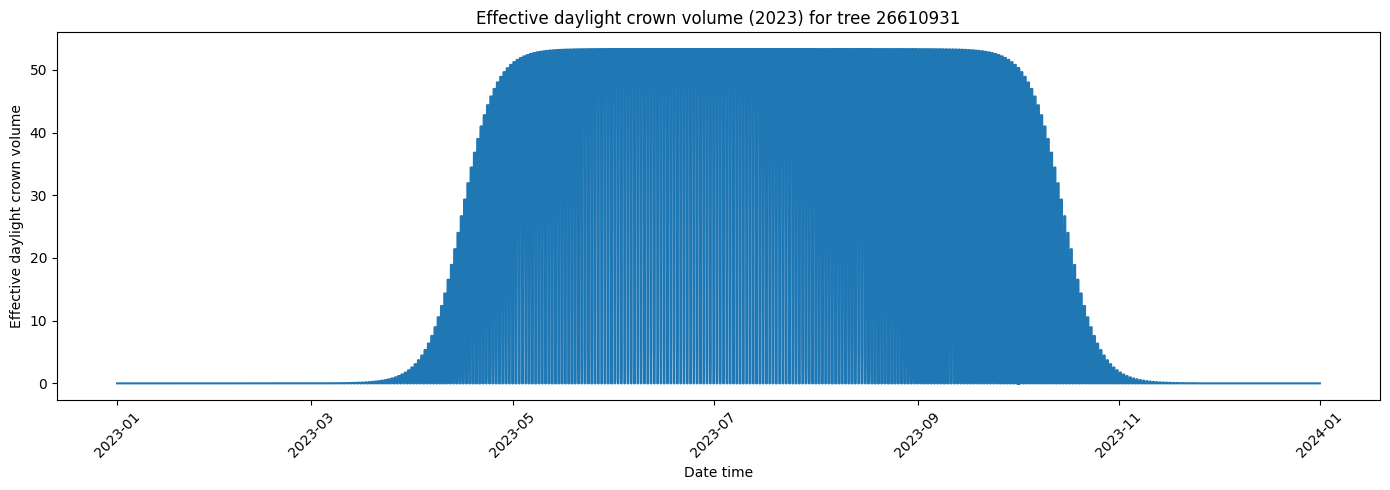

In [23]:
import matplotlib.pyplot as plt

example_tree = merged["OBJECTID"].dropna().iloc[0]

plot_df = merged[merged["OBJECTID"] == example_tree].copy()

plot_df = plot_df[
    (plot_df["DATE_TIME"] >= "2023-01-01") &
    (plot_df["DATE_TIME"] < "2024-01-01")
]

plt.figure(figsize=(14, 5))
plt.plot(plot_df["DATE_TIME"], plot_df["effective_daylight_crown_volume"])
plt.title(f"Effective daylight crown volume (2023) for tree {example_tree}")
plt.xlabel("Date time")
plt.ylabel("Effective daylight crown volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

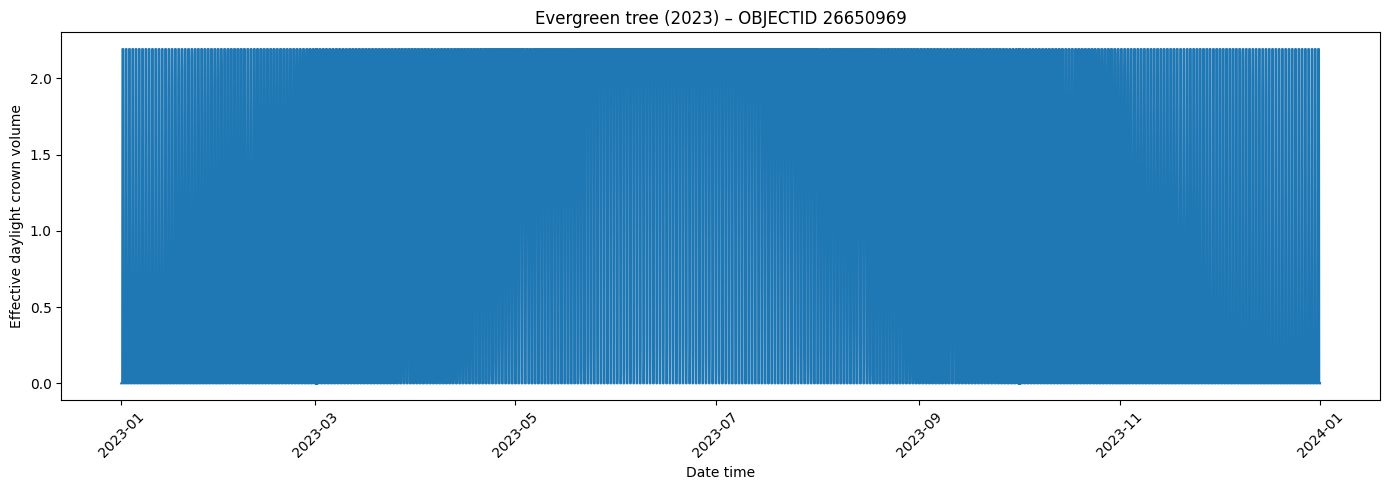

Crown volume of tree 26610931: 2.193200872582487


In [26]:
evergreen_species = [
    "Pine", "Cedar", "Yew", "Holly", "Spruce", "Fir"
]

evergreen_df = merged[
    merged["COMMON_NAME"].isin(evergreen_species)
]

example_evergreen = evergreen_df["OBJECTID"].dropna().iloc[0]

plot_df = merged[merged["OBJECTID"] == example_evergreen].copy()

plot_df = plot_df[
    (plot_df["DATE_TIME"] >= "2023-01-01") &
    (plot_df["DATE_TIME"] < "2024-01-01")
]

plt.figure(figsize=(14, 5))
plt.plot(plot_df["DATE_TIME"], plot_df["effective_daylight_crown_volume"])
plt.title(f"Evergreen tree (2023) – OBJECTID {example_evergreen}")
plt.xlabel("Date time")
plt.ylabel("Effective daylight crown volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#print the crown volume of the example tree
print(f"Crown volume of tree {example_tree}: {plot_df['CROWN_VOLUME'].iloc[0]}")